In [2]:
# imports
import numpy as np
import scipy.io
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [3]:
from matplotlib.font_manager import fontManager, FontProperties

path = "Figure_data/MYRIADPRO-REGULAR.OTF"
fontManager.addfont(path)
prop = FontProperties(fname=path)

# load all the data required for plotting

In [4]:
PCA_results = scipy.io.loadmat("Figure_data/PCA_results_plot.mat")
RSM_data = scipy.io.loadmat("Figure_data/RSM_Matrices.mat")
Reliability = scipy.io.loadmat("Figure_data/Validation_reliability.mat")
TFCE = scipy.io.loadmat("Figure_data/TFCE_results_5k_ALL.mat")
Dissociation = scipy.io.loadmat("Figure_data/Dissociation_Permutation.mat")
PCcorr = scipy.io.loadmat("Figure_data/PC_AATvsMAT.mat")
Feature_corr = scipy.io.loadmat("Figure_data/Features_correlation.mat")

## plot similarity matrices and associations

In [13]:
AAT_RSM = RSM_data['AAT_RSM']
QIP_RSM = RSM_data['QIP_RSM']
CLIP_RSM = RSM_data['CLIP_RSM']
EMO_RSM = RSM_data['EMO_RSM']

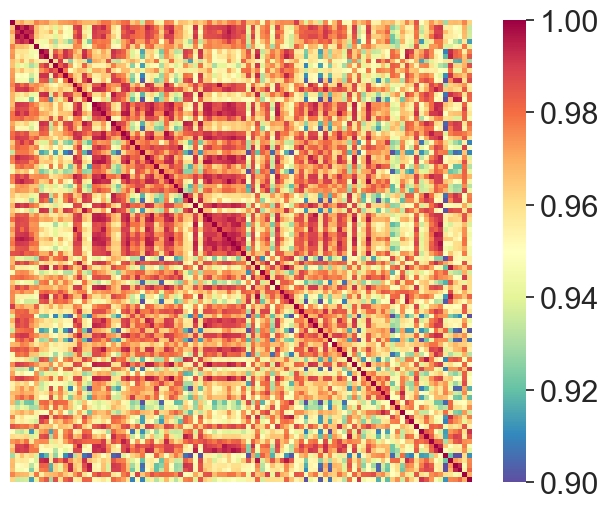

In [6]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(RSM_data['QIP_RSM'],cmap=cmap,vmin=0.9,vmax=1,center=0.95,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)

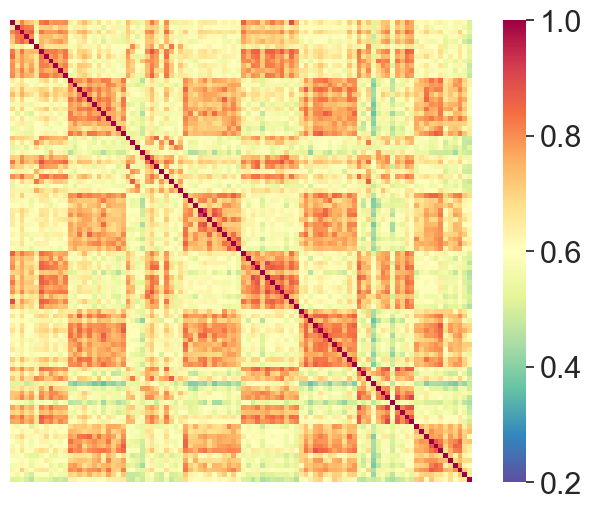

In [7]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(RSM_data['CLIP_RSM'],cmap=cmap,vmin=0.2,vmax=1,center=0.6,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)

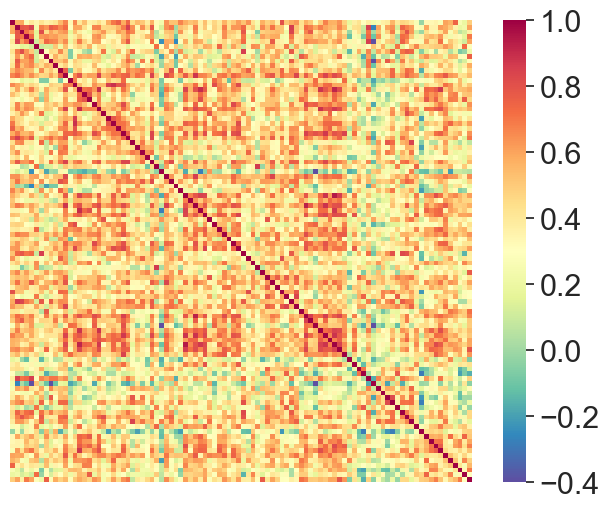

In [8]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(RSM_data['EMO_RSM'],cmap=cmap,vmin=-0.4,vmax=1,center=0.3,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)


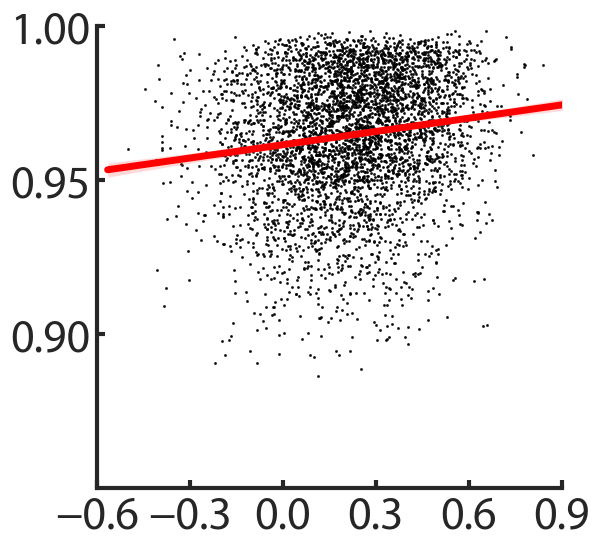

In [9]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(x=AAT_RSM[np.triu_indices(96, k=1)],y=QIP_RSM[np.triu_indices(96, k=1)], color="black",marker='.',scatter_kws={'s':5}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-0.6, 0.9), xticks=[-0.6,-0.3,0,0.3,0.6,0.9])
ax.set(ylim=(0.85, 1), yticks=[0.9,0.95,1])
ax.tick_params(axis="y",direction="in", pad=5,width=3)
ax.tick_params(axis="x",direction="in", pad=5,width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()


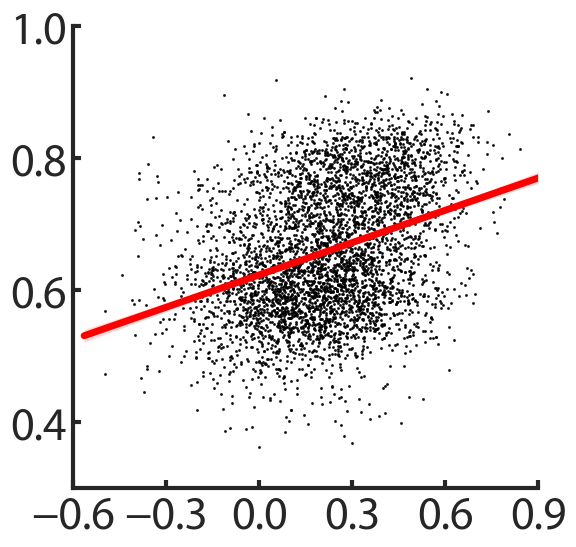

In [10]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(x=AAT_RSM[np.triu_indices(96, k=1)],y=CLIP_RSM[np.triu_indices(96, k=1)], color="black",marker='.',scatter_kws={'s':5}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-0.6, 0.9), xticks=[-0.6,-0.3,0,0.3,0.6,0.9])
ax.set(ylim=(0.3, 1), yticks=[0.4,0.6,0.8,1])
ax.tick_params(axis="y",direction="in", pad=5,width=3)
ax.tick_params(axis="x",direction="in", pad=5,width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

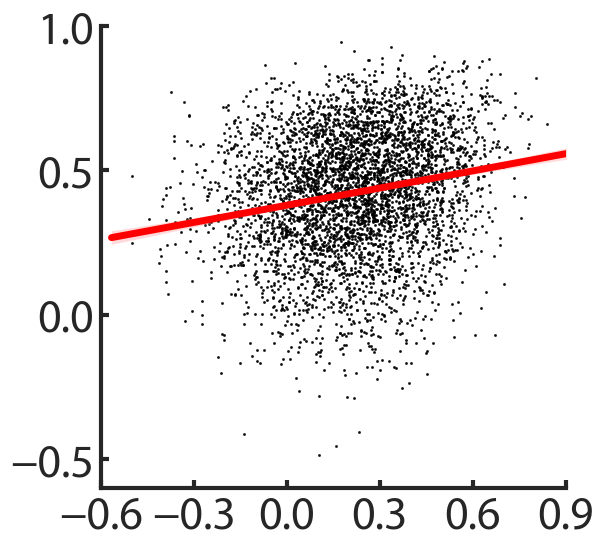

In [11]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(x=AAT_RSM[np.triu_indices(96, k=1)],y=EMO_RSM[np.triu_indices(96, k=1)], color="black",marker='.',scatter_kws={'s':5}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-0.6, 0.9), xticks=[-0.6,-0.3,0,0.3,0.6,0.9])
ax.set(ylim=(-0.6, 1), yticks=[-0.5,0,0.5,1])
ax.tick_params(axis="y",direction="in", pad=5,width=3)
ax.tick_params(axis="x",direction="in", pad=5,width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()


## reliability of aesthetic agreement matrix

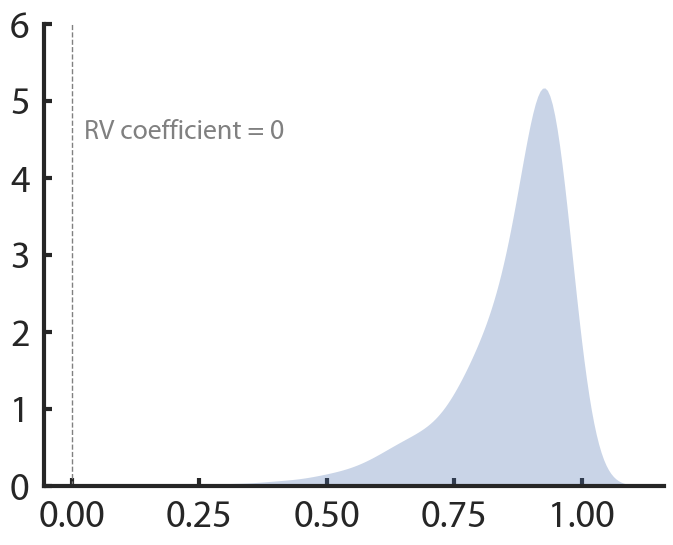

In [12]:
sns.set_context("talk")
sns.set(font_scale=2.5, style="ticks", rc={'figure.figsize': (8,6)}, font=prop.get_name())
ax_rl = sns.kdeplot(data=Reliability['RV_mat_boot'],legend=False,bw_adjust=1.5,fill=True,color='lightblue', alpha=.3, linewidth=0)
plt.vlines(0,0,6,colors='grey',linestyles='--',linewidth=1) 
plt.text(0.025,4.5,'RV coefficient = 0',fontsize=20,color='grey')
ax_rl.tick_params(axis='x', direction="in", pad=10, width=3)
ax_rl.tick_params(axis="y", direction="in", pad=10, width=3)
ax_rl.set(ylim=(0, 6), yticks=[0, 1, 2, 3, 4, 5, 6])
#ax_rl.set(xlim=(0,1), xticks=[1,2,3,4,5,6,7,8,9,10])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

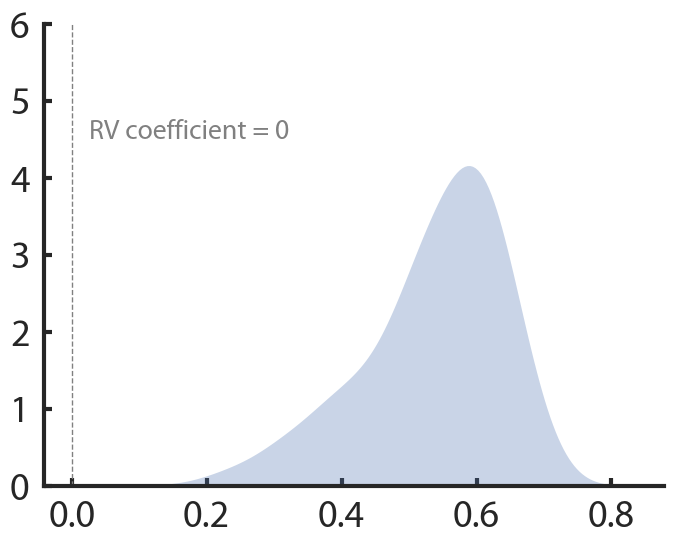

In [13]:
sns.set_context("talk")
sns.set(font_scale=2.5, style="ticks", rc={'figure.figsize': (8,6)}, font=prop.get_name())
ax_rl = sns.kdeplot(data=Reliability['RV_mat_splithalf'],legend=False,bw_adjust=1.5,fill=True,color='lightblue', alpha=.3, linewidth=0)
plt.vlines(0,0,6,colors='grey',linestyles='--',linewidth=1) 
plt.text(0.025,4.5,'RV coefficient = 0',fontsize=20,color='grey')
ax_rl.tick_params(axis='x', direction="in", pad=10, width=3)
ax_rl.tick_params(axis="y", direction="in", pad=10, width=3)
ax_rl.set(ylim=(0, 6), yticks=[0, 1, 2, 3, 4, 5, 6])
#ax_rl.set(xlim=(0,1), xticks=[1,2,3,4,5,6,7,8,9,10])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

## stability of PCA solution

In [14]:
dims_rc_sh = Reliability["trr_splithalf_scores"]
dims_rc_bt = Reliability["r_boot_scores"]
stru_ci_sh = Reliability["CI_struct_splithalf"]
stru_ci_bt = Reliability["CI_struct_boot"]

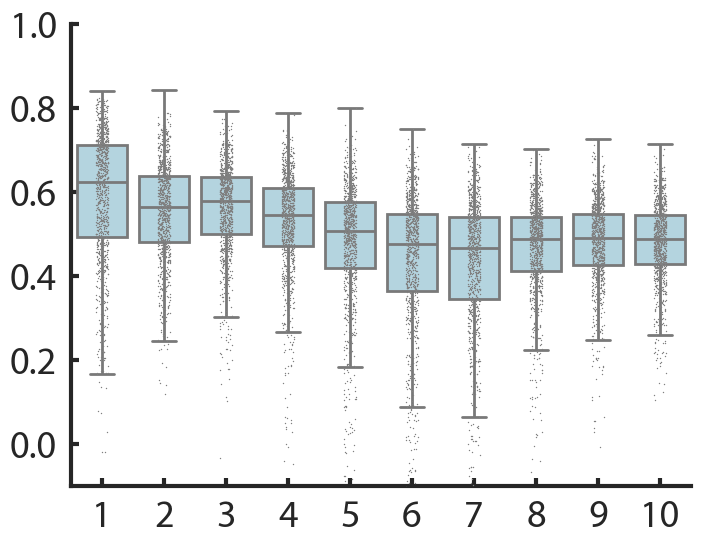

In [15]:
df = pd.DataFrame(dims_rc_sh)
df_long = df.melt(var_name="iteration", value_name="Reliability")
df_long["Components"] = np.tile(np.arange(10) + 1, 1000)

sns.set(font_scale=2.5, style="ticks", rc={'figure.figsize': (8,6)}, font=prop.get_name())
ax_rl = sns.boxplot(data=df_long, x="Components", y="Reliability", linewidth=2, fliersize=0,color='lightblue')
sns.stripplot(data=df_long, x="Components", y="Reliability", size=1, color='gray')

ax_rl.tick_params(axis='x', direction="in", pad=10, width=3)
ax_rl.tick_params(axis="y", direction="in", pad=10, width=3)
ax_rl.set(ylim=(-0.1, 1), yticks=[0, 0.2, 0.4, 0.6, 0.8, 1])
#ax_rl.set(xlim=(0,1), xticks=[1,2,3,4,5,6,7,8,9,10])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

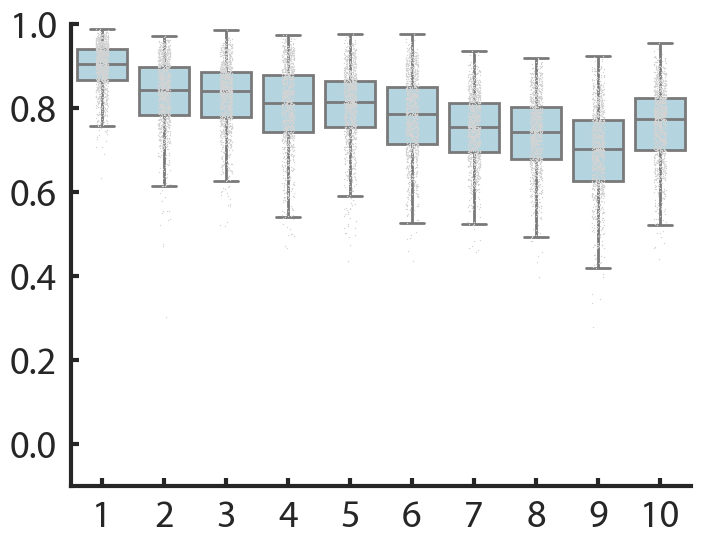

In [16]:
df = pd.DataFrame(dims_rc_bt)
df_long = df.melt(var_name="iteration", value_name="Reliability")
df_long["Components"] = np.tile(np.arange(10) + 1, 1000)

sns.set(font_scale=2.5, style="ticks", rc={'figure.figsize': (8,6)}, font=prop.get_name())
ax_rl = sns.boxplot(data=df_long, x="Components", y="Reliability", linewidth=2, fliersize=0,color='lightblue')
sns.stripplot(data=df_long, x="Components", y="Reliability", size=1, color='lightgray')

ax_rl.tick_params(axis='x', direction="in", pad=10, width=3)
ax_rl.tick_params(axis="y", direction="in", pad=10, width=3)
ax_rl.set(ylim=(-0.1, 1), yticks=[0, 0.2, 0.4, 0.6, 0.8, 1])
#ax_rl.set(xlim=(0,1), xticks=[1,2,3,4,5,6,7,8,9,10])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

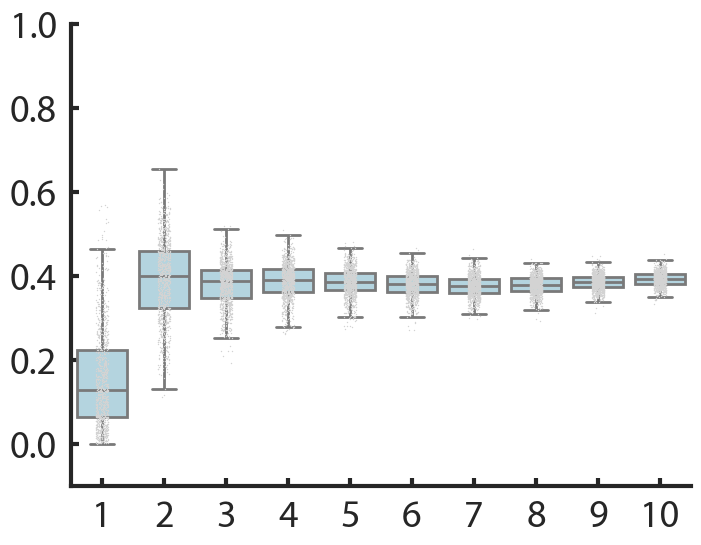

In [17]:
df = pd.DataFrame(stru_ci_sh)
df_long = df.melt(var_name="iteration", value_name="Reliability")
df_long["Components"] = np.tile(np.arange(10) + 1, 1000)

sns.set(font_scale=2.5, style="ticks", rc={'figure.figsize': (8,6)}, font=prop.get_name())
ax_rl = sns.boxplot(data=df_long, x="Components", y="Reliability", linewidth=2, fliersize=0,color='lightblue')
sns.stripplot(data=df_long, x="Components", y="Reliability", size=1, color='lightgray')

ax_rl.tick_params(axis='x', direction="in", pad=10, width=3)
ax_rl.tick_params(axis="y", direction="in", pad=10, width=3)
ax_rl.set(ylim=(-0.1, 1), yticks=[0, 0.2, 0.4, 0.6, 0.8, 1])
#ax_rl.set(xlim=(0,1), xticks=[1,2,3,4,5,6,7,8,9,10])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

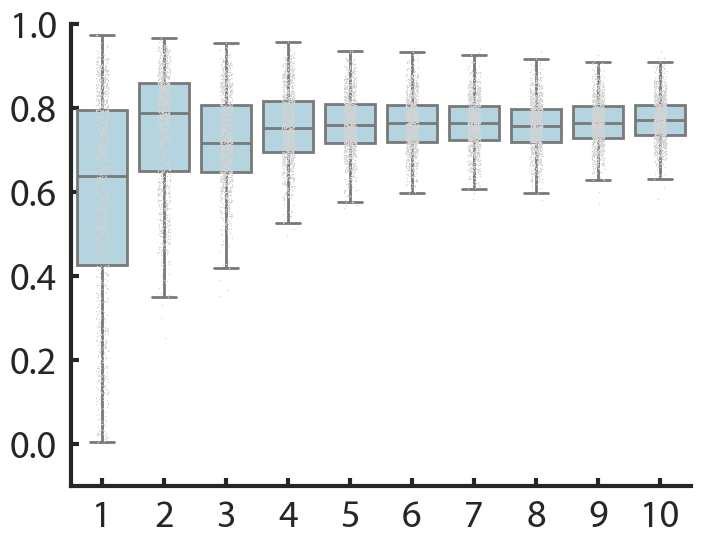

In [18]:
df = pd.DataFrame(stru_ci_bt)
df_long = df.melt(var_name="iteration", value_name="Reliability")
df_long["Components"] = np.tile(np.arange(10)+1, 1000)

sns.set(font_scale=2.5,style="ticks",rc={'figure.figsize':(8,6)},font=prop.get_name())
ax_rl = sns.boxplot(data=df_long,x="Components",y="Reliability",linewidth=2, fliersize=0,color='lightblue')
sns.stripplot(data=df_long,x="Components",y="Reliability", size=1,color='lightgray')

ax_rl.tick_params(axis='x', direction="in", pad=10,width=3)
ax_rl.tick_params(axis="y",direction="in", pad=10,width=3)
ax_rl.set(ylim=(-0.1,1), yticks=[0,0.2,0.4,0.6,0.8,1])
#ax_rl.set(xlim=(0,1), xticks=[1,2,3,4,5,6,7,8,9,10])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

## PCA on aesthetic agreement matrix

In [20]:
PCA_loadings = PCA_results["loadings"]
PCA_eigenvalues = PCA_results["actual_eigenvalues"]
PCA_pa_values = PCA_results["pa_eigenvalues_95"]
PCA_cumExplained = PCA_results["cumExplained"]
PCA_explained = PCA_results["explained"]

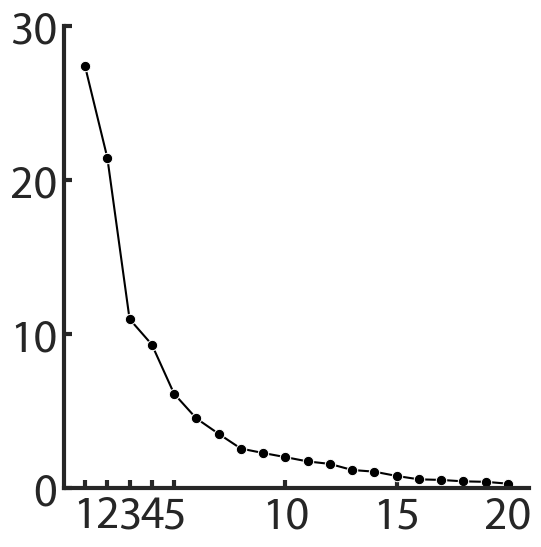

In [21]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.lineplot(x=range(1, len(PCA_explained[0:20]) + 1), y=PCA_explained[0:20,0], markers=True,marker='.',markersize=15, markerfacecolor='black',color='black')
#plt.plot(1, pca_res.explained_variance_ratio_[0], 'ro',markersize=15) # 'bo' means blue circle marker
#plt.plot(2, pca_res.explained_variance_ratio_[1], 'ro',markersize=15) # 'bo' means blue circle marker

ax.set(xlabel='Components', ylabel='Explained Variance (%)')
ax.set(xticks=[1,2,3,4,5,10,15,20])
ax.set(ylim=(0, 30), yticks=[0,10,20,30])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.set(xlabel='', ylabel='')
sns.despine()

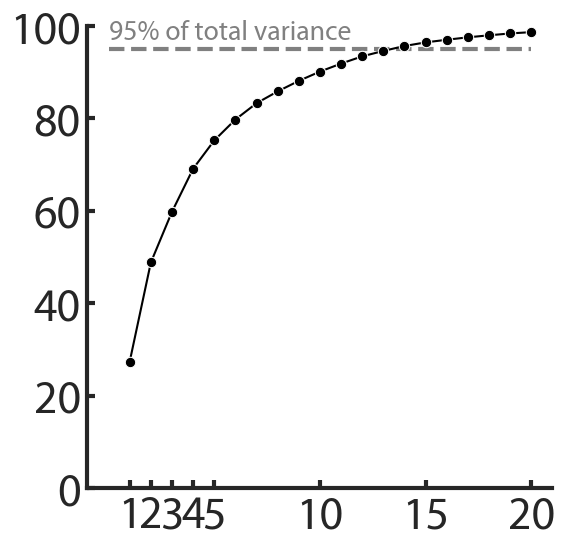

In [22]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
plt.hlines(95,0,20,colors='grey',linestyles='--',linewidth=3) 
plt.text(0,97,'95% of total variance',fontsize=20,color='grey')

ax=sns.lineplot(x=range(1, len(PCA_cumExplained[0:20]) + 1), y=PCA_cumExplained[0:20,0], markers=True,marker='.',markersize=15, markerfacecolor='black',color='black')
#plt.plot(1, pca_res.explained_variance_ratio_[0], 'ro',markersize=15) # 'bo' means blue circle marker
#plt.plot(2, pca_res.explained_variance_ratio_[1], 'ro',markersize=15) # 'bo' means blue circle marker

ax.set(xlabel='Components', ylabel='Explained Variance (%)')
ax.set(xticks=[1,2,3,4,5,10,15,20])
ax.set(ylim=(0, 100), yticks=[0,20,40,60,80,100])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.set(xlabel='', ylabel='')

sns.despine()

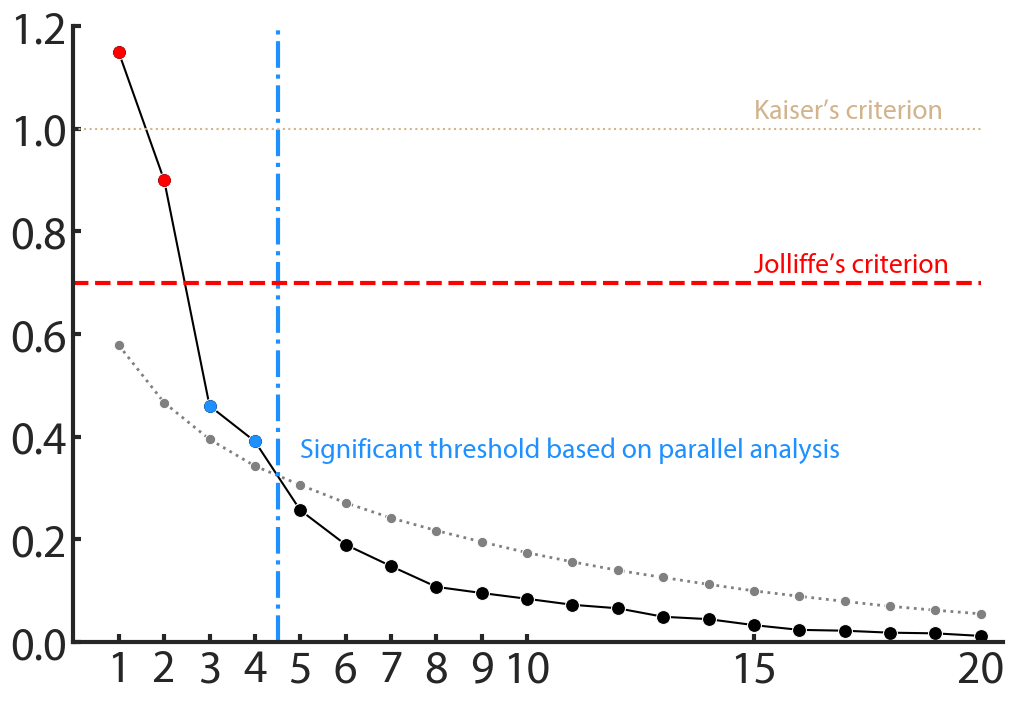

In [23]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(12,8)},font=prop.get_name())
ax=sns.lineplot(x=range(1, 20 + 1), y=PCA_eigenvalues[0,0:20], markers=True,marker='.',markersize=20, markerfacecolor='black',color='black')
ax=sns.lineplot(x=range(1, 20 + 1), y=PCA_pa_values[0,0:20],markers=True,marker='.',markersize=15, markerfacecolor='grey',color='grey',linestyle=':',linewidth=2)

plt.plot(1, PCA_eigenvalues[0,0], 'o',color = 'red', markersize=8) # 'bo' means blue circle marker
plt.plot(2, PCA_eigenvalues[0,1], 'o',color = 'red',markersize=8) # 'bo' means blue circle marker

plt.plot(3, PCA_eigenvalues[0,2], 'o',color = 'dodgerblue',markersize=8) # 'bo' means blue circle marker
plt.plot(4, PCA_eigenvalues[0,3], 'o',color = 'dodgerblue',markersize=8) # 'bo' means blue circle marker

plt.vlines(4.5,0,1.2,colors='dodgerblue',linestyles='-.',linewidth=3) 
plt.hlines(0.7,0,20,colors='red',linestyles='--',linewidth=3) 
plt.hlines(1,0,20,colors='tan',linestyles=':') 
plt.text(15,1.02,'Kaiser’s criterion',fontsize=20,color='tan')
plt.text(15,0.72,'Jolliffe’s criterion',fontsize=20,color='red')
plt.text(5,0.36,'Significant threshold based on parallel analysis',fontsize=20,color='dodgerblue')


ax.set(xlabel='Components', ylabel='Eigenvalues')
ax.set(xticks=[1,2,3,4,5,6,7,8,9,10,15,20])
ax.set(xlim=(0, 20.5))
ax.set(ylim=(0, 1.2), yticks=[0,0.2,0.4,0.6,0.8,1,1.2])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.set(xlabel='', ylabel='')

sns.despine()

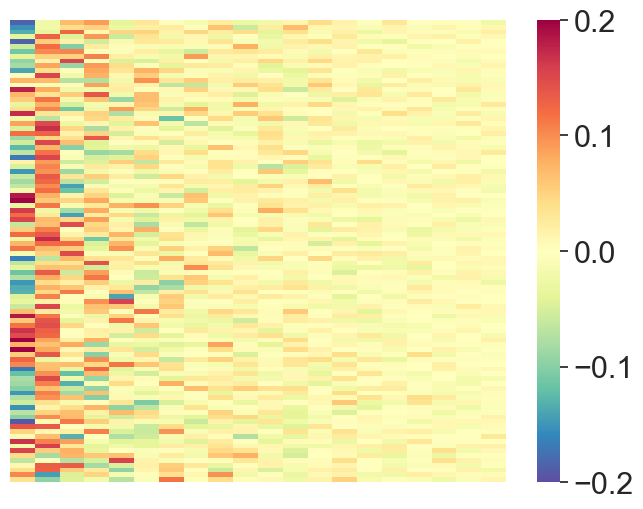

In [24]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(PCA_loadings[:,0:20],cmap=cmap,vmin=-0.2,vmax=0.2,center=0,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)

## permutation results for cross-prediction

In [25]:
Real_data = Dissociation['crossprediction_data_plot']
Random_data1 = Dissociation['dist_diff_model1']
Random_data2 = Dissociation['dist_diff_model2']

In [26]:
Random_values1 = np.mean(Random_data1,axis=1)
Random_values2 = np.mean(Random_data2,axis=1)
Real_value1 = np.mean(Real_data[:,1]-Real_data[:,0],axis=0)
Real_value2 = np.mean(Real_data[:,2]-Real_data[:,3],axis=0)

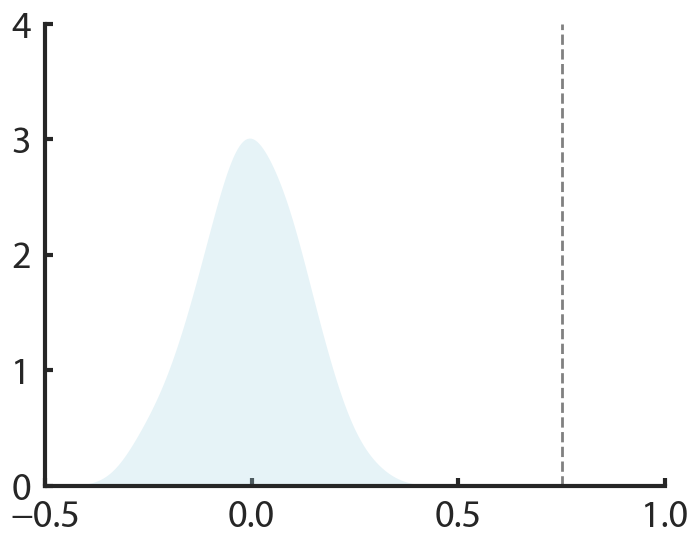

In [27]:
sns.set_context("talk")
sns.set(font_scale=2.5, style="ticks", rc={'figure.figsize': (8,6)}, font=prop.get_name())
ax_rl = sns.kdeplot(data=Random_values1,legend=False,bw_adjust=1.5,fill=True,color='lightblue', alpha=.3, linewidth=0)
plt.vlines(Real_value1,0,4,colors='grey',linestyles='--',linewidth=2) 
#plt.text(0.025,4.5,'Real mean accuracy difference of semantic model',fontsize=20,color='grey')
ax_rl.tick_params(axis='x', direction="in", pad=10, width=3)
ax_rl.tick_params(axis="y", direction="in", pad=10, width=3)
ax_rl.set(ylim=(0, 4), yticks=[0, 1, 2, 3, 4])
ax_rl.set(xlim=(-0.5,1), xticks=[-0.5,0,0.5,1])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

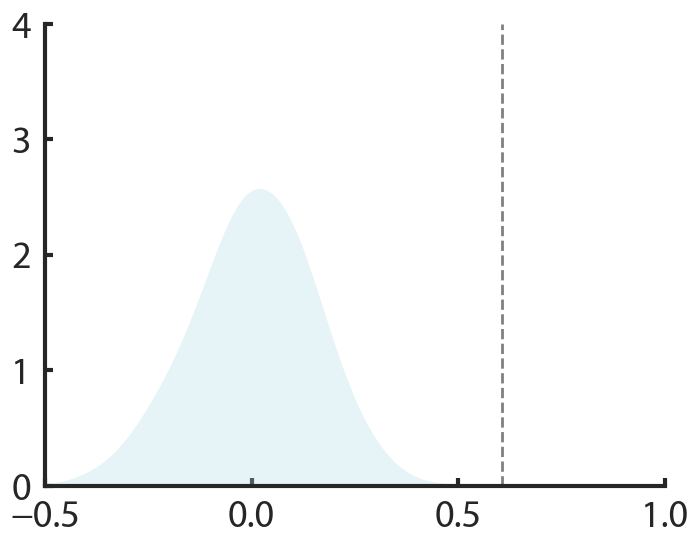

In [28]:
sns.set_context("talk")
sns.set(font_scale=2.5, style="ticks", rc={'figure.figsize': (8,6)}, font=prop.get_name())
ax_rl = sns.kdeplot(data=Random_values2,legend=False,bw_adjust=1.5,fill=True,color='lightblue', alpha=.3, linewidth=0)
plt.vlines(Real_value2,0,4,colors='grey',linestyles='--',linewidth=2) 
#plt.text(0.025,4.5,'Real mean accuracy difference of value model',fontsize=20,color='grey')
ax_rl.tick_params(axis='x', direction="in", pad=10, width=3)
ax_rl.tick_params(axis="y", direction="in", pad=10, width=3)
ax_rl.set(ylim=(0, 4), yticks=[0, 1, 2, 3, 4])
ax_rl.set(xlim=(-0.5,1), xticks=[-0.5,0,0.5,1])
ax_rl.set(xlabel='', ylabel='')
ax_rl.spines['bottom'].set_linewidth(3)
ax_rl.spines['left'].set_linewidth(3)
sns.despine()

## PCA on semantic similarity matrix from MAT task

In [12]:
# load the stimulus images 
circleimages = np.load('Figure_data/circleimages.npy')
MAT_avg = np.load('Figure_data/MAT_avg_matrix.npy')

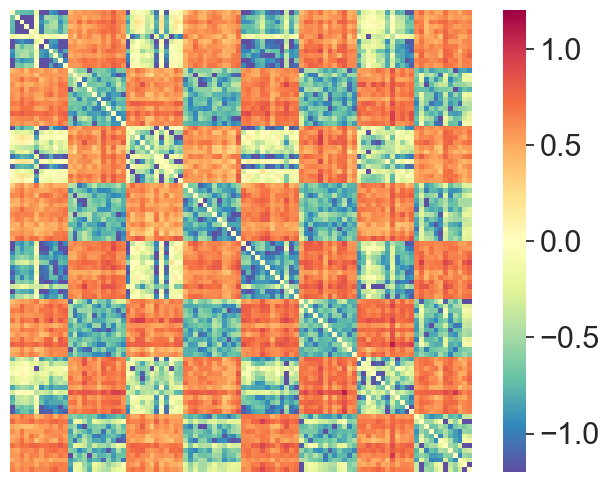

In [7]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
#cmap = sns.diverging_palette(220, 10, as_cmap = True)
#cmap = sns.color_palette("viridis", as_cmap=True)
cmap = sns.color_palette(palette="Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(MAT_avg,cmap=cmap,vmin=-1.2,vmax=1.2,center=0,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)

In [10]:
pca_MAT = PCA(n_components=10)
pca_MAT.fit(MAT_avg)
MAT_pc= pca_MAT.transform(MAT_avg)

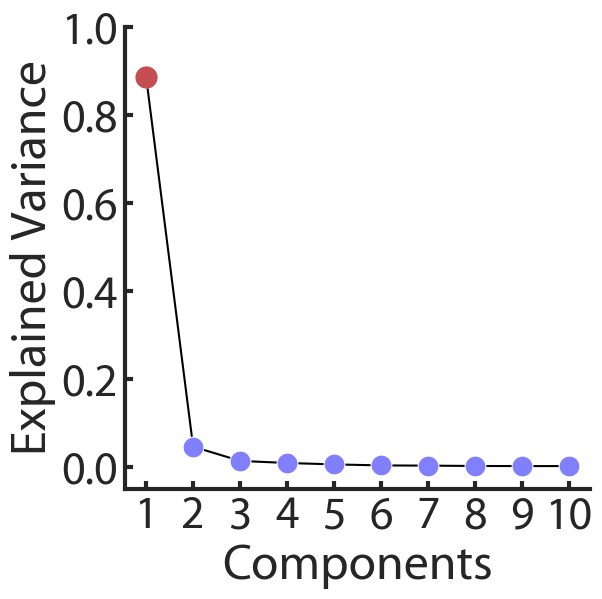

In [11]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.lineplot(x=range(1, len(pca_MAT.explained_variance_ratio_) + 1), y=pca_MAT.explained_variance_ratio_, markers=True,marker='o',markersize=15,markerfacecolor='#8080ff',color='black')
plt.plot(1, pca_MAT.explained_variance_ratio_[0], 'ro',markersize=15) # 'bo' means blue circle marker

ax.set(xlabel='Components', ylabel='Explained Variance')
ax.set(xticks=[1,2,3,4,5,6,7,8,9,10])
ax.set(ylim=(-0.05, 1), yticks=[0,0.2,0.4,0.6,0.8,1])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

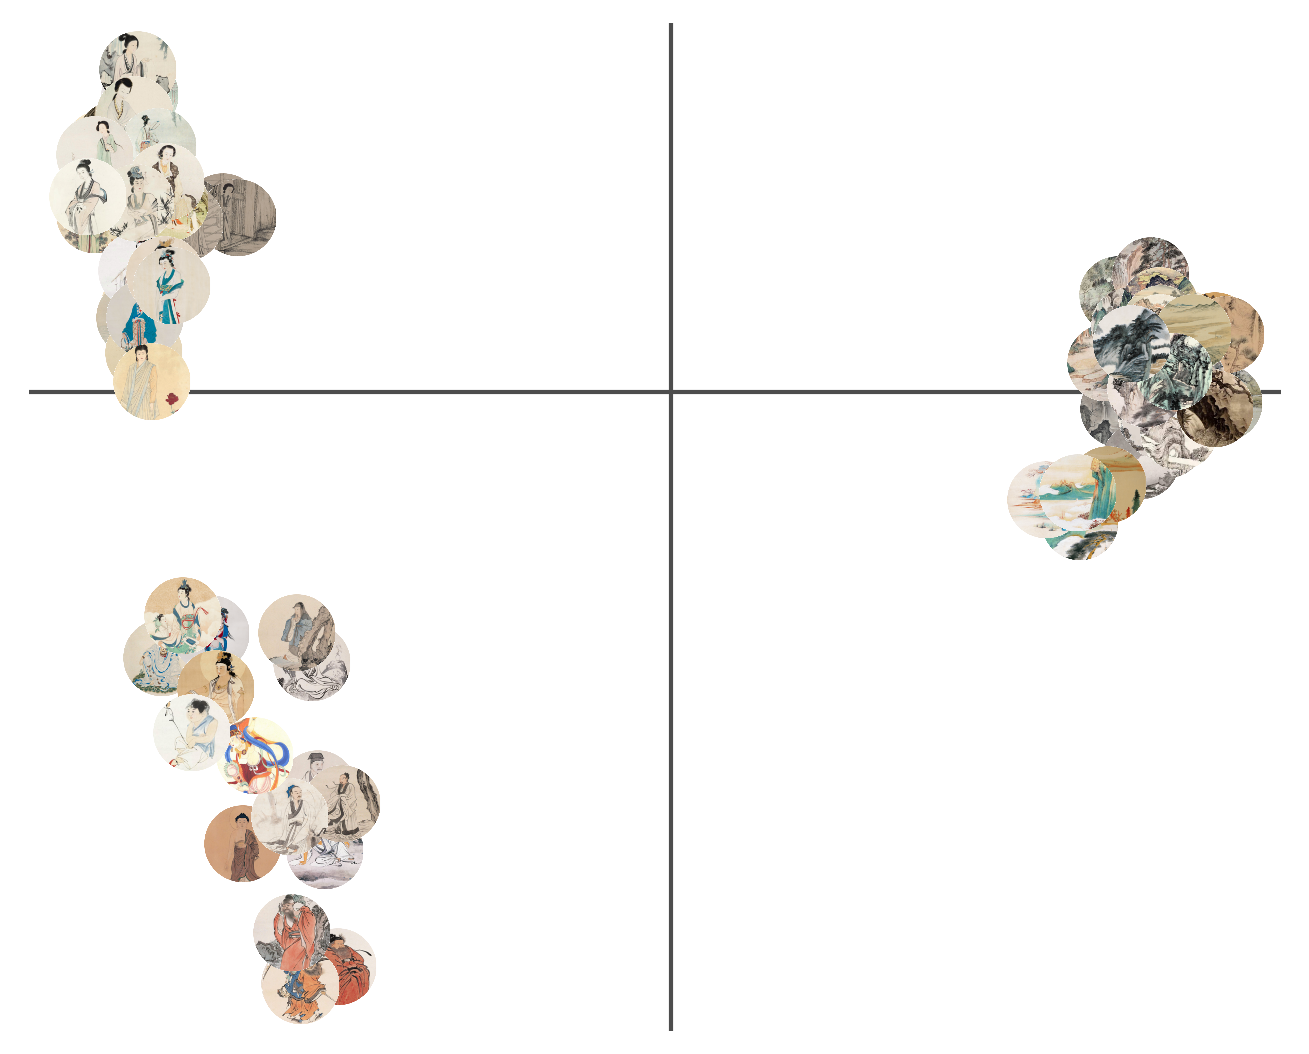

In [12]:
sns.set_style("white")
sns.set_context("talk")
fig, ax = plt.subplots(figsize=(15, 12))
ax.scatter(-MAT_pc[:, 0], MAT_pc[:, 1])
ax.set(xticklabels=[],xlabel=None,yticklabels=[],ylabel=None)
ax.axhline(0, color=".3", linewidth=3)
ax.axvline(0, color=".3", linewidth=3)
for x0, y0, img in zip(-MAT_pc[:, 0], MAT_pc[:, 1], circleimages):
    # set the background outside circle as transparent
    alpha = ~np.all(img == 255, axis=2) * 255
    img[:, :, 3] = alpha

    # plot single image
    im = OffsetImage(img, zoom=0.15)
    ab = AnnotationBbox(im, (x0, y0), frameon=False)
    ax.add_artist(ab)
plt.axis('on')
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()

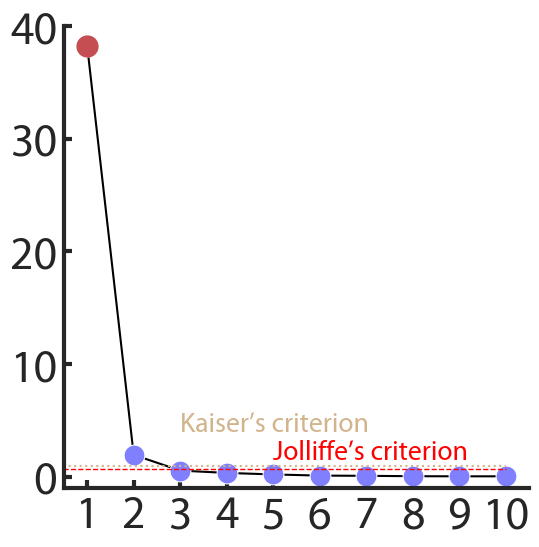

In [13]:
MAT_PCA_eigenvalues = PCcorr["latent_mat"]
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.lineplot(x=range(1, 10 + 1), y=MAT_PCA_eigenvalues[0:10,0], markers=True,marker='o',markersize=15,markerfacecolor='#8080ff',color='black')
plt.plot(1, MAT_PCA_eigenvalues[0,0], 'ro',markersize=15) # 'bo' means blue circle marker

plt.hlines(0.7,0,10,colors='red',linestyles='--',linewidth=1) 
plt.hlines(1,0,10,colors='tan',linestyles=':') 
plt.text(3,4,'Kaiser’s criterion',fontsize=20,color='tan')
plt.text(5,1.5,'Jolliffe’s criterion',fontsize=20,color='red')

#ax.set(xlabel='Components', ylabel='Explained Variance')
ax.set(xlim=(0.5, 10.5),xticks=[1,2,3,4,5,6,7,8,9,10])
ax.set(ylim=(-1, 40), yticks=[0,10,20,30,40])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()



In [31]:
df = pd.DataFrame({'variable' : [x for x in range(0, 831)], 'pvalue' : Feature_corr['p_axq'][0,:].T,
                'category' : np.concatenate((np.repeat('Low-level visual',43,0),np.repeat('High-level semantics',768,0),np.repeat('Affective',20,0))).tolist()})
# -log_10(pvalue)
df['minuslog10pvalue'] = -np.log10(df.pvalue)

# How to plot gene vs. -log10(pvalue) and colour it by chromosome?
df['ind'] = range(len(df))
df_grouped = df.groupby(('category'))

/Users/liangxinyu/miniforge3/envs/nat/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


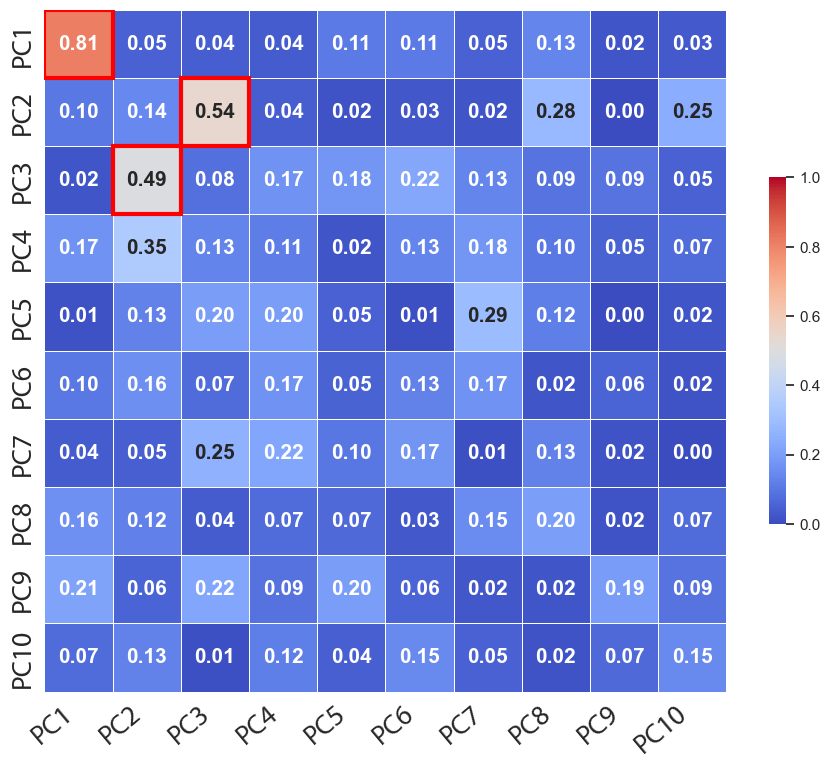

In [32]:
sns.set_theme(style="white")

# Generate a large random dataset
d = pd.DataFrame(data=np.abs(PCcorr['r_axs']),columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])

# Generate a mask for the upper triangle
#mask = np.triu(np.ones_like(PCcorr['r_axs'], dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
#cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
g = sns.heatmap(d, cmap="coolwarm", vmax=1, vmin=0,center=0.5,annot=True, fmt=".2f",
                annot_kws={"fontsize":15,"fontweight": 'bold'},square=True, linewidths=.5, cbar_kws={"shrink": .5},
                yticklabels=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])
g.set(xlabel="", ylabel="", aspect="equal")
#plt.xticks(rotation=30, ha= 'right', fontsize=12)
#plt.yticks(fontsize=12)
ax.tick_params(axis="y", pad=0)
ax.tick_params(axis="x", pad=0)
g.set_yticklabels(g.get_yticklabels(), fontproperties=prop, fontsize=20)
g.set_xticklabels(g.get_xticklabels(), fontproperties=prop, ha= 'right', rotation=40, fontsize=20)


ax.add_patch(Rectangle((0,0),1,1, fill=False, edgecolor='red', lw=3))
ax.add_patch(Rectangle((1,2),1,1, fill=False, edgecolor='red', lw=3))
ax.add_patch(Rectangle((2,1),1,1, fill=False, edgecolor='red', lw=3))


## associations between objective images features and latent aesthetic components

/Users/liangxinyu/miniforge3/envs/nat/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


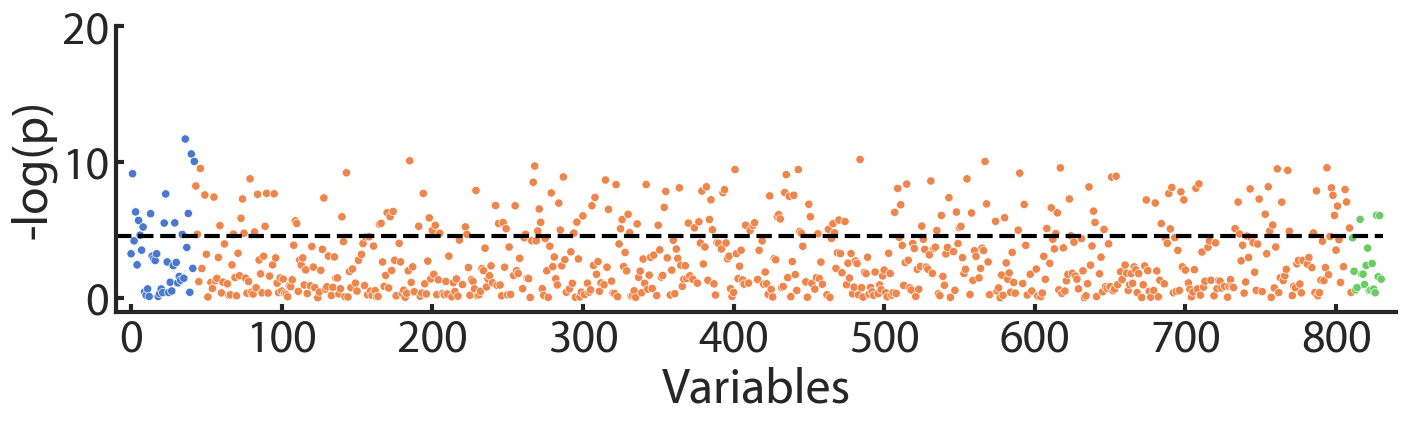

In [33]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(12,8), "axes.linewidth": 3},font=prop.get_name())
# sample data
df = pd.DataFrame({'variable' : [x for x in range(0, 831)], 'pvalue' : Feature_corr['p_axq'][0,:].T,
                'category' : np.concatenate((np.repeat('Low-level visual',43,0),np.repeat('High-level semantics',768,0),np.repeat('Affective',20,0))).tolist()})

# -log_10(pvalue)
df['minuslog10pvalue'] = -np.log10(df.pvalue)

# How to plot gene vs. -log10(pvalue) and colour it by chromosome?
df['ind'] = range(len(df))
df_grouped = df.groupby(('category'))

# manhattan plot
ax = sns.relplot(data=df, x='variable', y='minuslog10pvalue', aspect=3, 
                   hue='category', palette = 'muted', legend=None) 

plt.hlines(-np.log10(0.05/831/2),-10,831,colors='black',linestyles='--',linewidth=3)
#plt.text(200,10,'Bonferroni corrected p < 0.05',fontsize=20,color='black')



ax.set(xlim=(-10, 840))
ax.set(ylim=(-1, 20))

ax.set(xlabel='Variables', ylabel='-log(p)')
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)




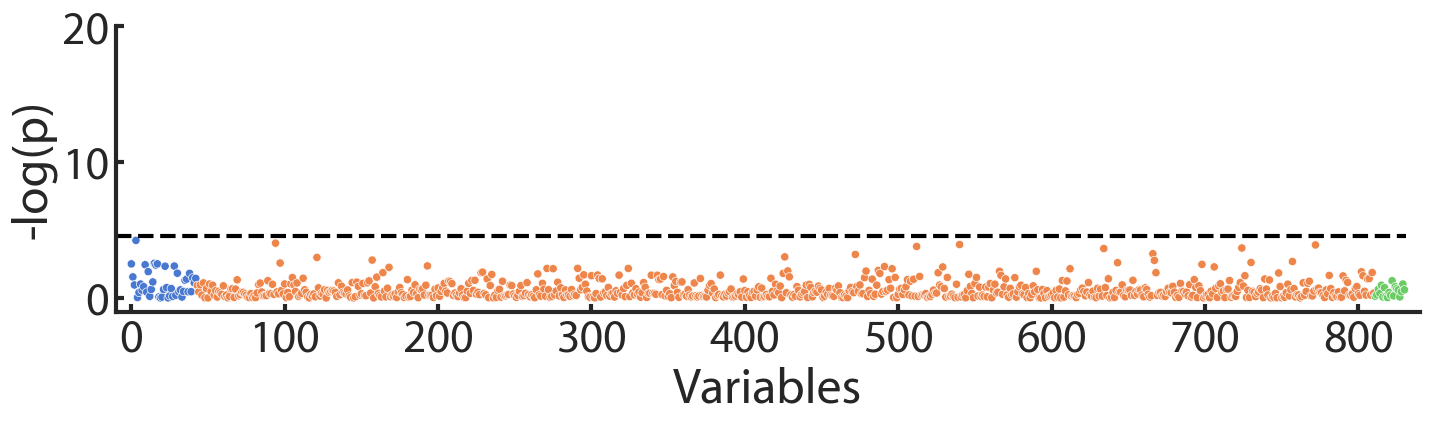

In [34]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(12,8), "axes.linewidth": 3},font=prop.get_name())
# sample data
df = pd.DataFrame({'variable' : [x for x in range(0, 831)], 'pvalue' : Feature_corr['p_axq'][1,:].T,
                'category' : np.concatenate((np.repeat('Low-level visual',43,0),np.repeat('High-level semantics',768,0),np.repeat('Affective',20,0))).tolist()})

# -log_10(pvalue)
df['minuslog10pvalue'] = -np.log10(df.pvalue)

# How to plot gene vs. -log10(pvalue) and colour it by chromosome?
df['ind'] = range(len(df))
df_grouped = df.groupby(('category'))

# manhattan plot
ax = sns.relplot(data=df, x='variable', y='minuslog10pvalue', aspect=3, 
                   hue='category', palette = 'muted', legend=None) 

plt.hlines(-np.log10(0.05/831/2),-10,831,colors='black',linestyles='--',linewidth=3)
#plt.text(200,6,'Bonferroni corrected p < 0.05',fontsize=20,color='black')


ax.set(xlim=(-10, 840))
ax.set(ylim=(-1, 20))

ax.set(xlabel='Variables', ylabel='-log(p)')
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)


## dice coefficient among cortical RSA searchlight results

[Text(0.5, 0, 'Euclidean_sl50 (Main)'),
 Text(1.5, 0, 'zEuclidean_sl50'),
 Text(2.5, 0, 'Mahalanobis_sl50'),
 Text(3.5, 0, 'Euclidean_sl10'),
 Text(4.5, 0, 'Euclidean_sl20'),
 Text(5.5, 0, 'Euclidean_sl30'),
 Text(6.5, 0, 'Euclidean_sl40')]

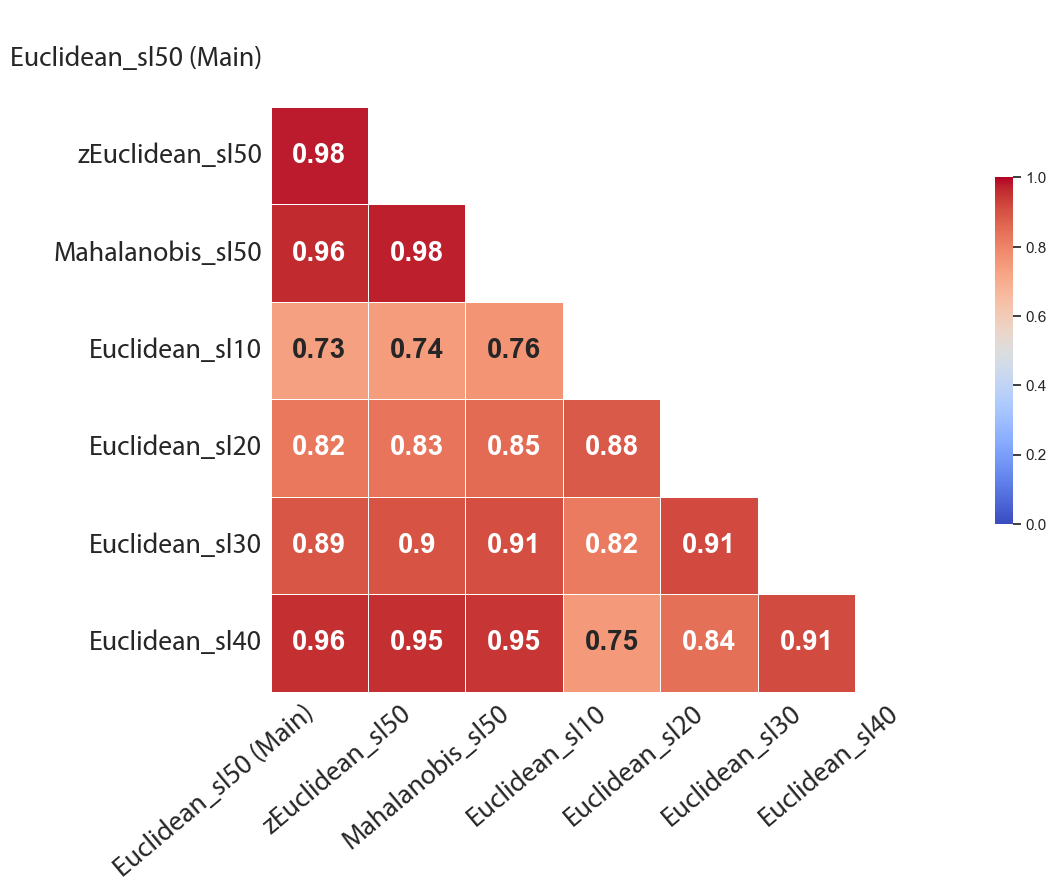

In [35]:
sns.set_theme(style="white")

# Generate a large random dataset
d = pd.DataFrame(data=TFCE['dice_all'],
                 columns=['Euclidean_sl50 (Main)','zEuclidean_sl50','Mahalanobis_sl50','Euclidean_sl10','Euclidean_sl20','Euclidean_sl30','Euclidean_sl40'])

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(TFCE['dice_all'], dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
#cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
g = sns.heatmap(d, mask=mask, cmap="coolwarm", vmax=1, vmin=0,center=0.5,annot=True,
                annot_kws={"fontsize":20,"fontweight": 'bold'},square=True, linewidths=.5, cbar_kws={"shrink": .5},yticklabels=['Euclidean_sl50 (Main)','zEuclidean_sl50','Mahalanobis_sl50','Euclidean_sl10','Euclidean_sl20','Euclidean_sl30','Euclidean_sl40'])
g.set(xlabel="", ylabel="", aspect="equal")
#plt.xticks(rotation=30, ha= 'right', fontsize=12)
#plt.yticks(fontsize=12)
ax.tick_params(axis="y", pad=0)
ax.tick_params(axis="x", pad=0)
g.set_yticklabels(g.get_yticklabels(), fontproperties=prop, fontsize=20)
g.set_xticklabels(g.get_xticklabels(), fontproperties=prop, ha= 'right', rotation=40, fontsize=20)


In [7]:
pca_res = PCA(n_components=10)
pca_res.fit(res)
AAT_pc = pca_res.transform(res)
ind_portrait = np.bool_(np.tile(np.repeat([1,0],12),4))
ind_landscape = np.bool_(np.tile(np.repeat([0,1],12),4))

In [8]:
SE = scipy.io.loadmat('Figure_data/SignatureExpression_2d.mat')
#%%
s1exp = SE['g1_response_group'].T
s2exp = SE['g2_response_group'].T
#%%
s1exp = s1exp[0]
s2exp = s2exp[0]

NameError: name 'AAT_pc' is not defined

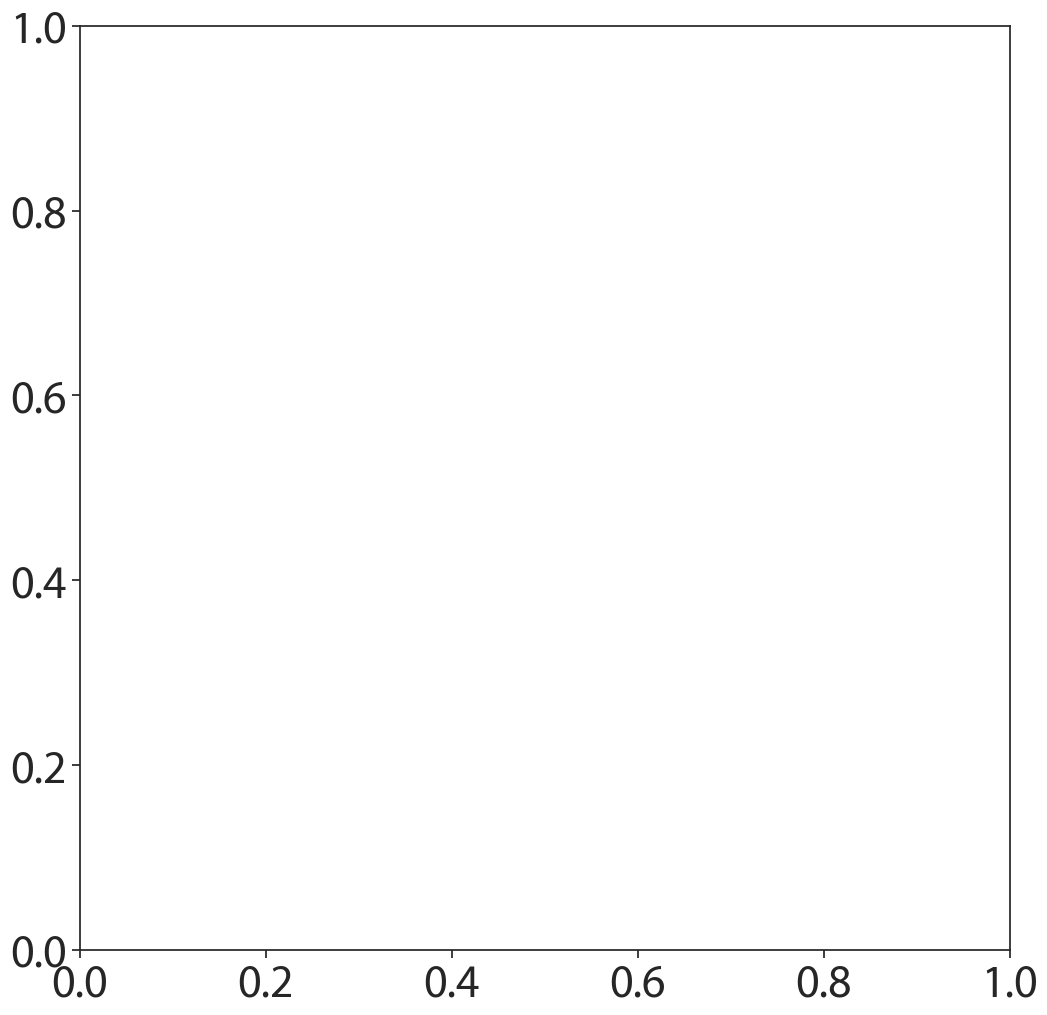

In [9]:
#sns.set_style("ticks")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(12,12)},font=prop.get_name())

fig, ax = plt.subplots(figsize=(12, 12))
ax = sns.regplot(x=s1exp[ind_portrait],y=AAT_pc[ind_portrait, 0],line_kws={"color": "orangered","linewidth":5},ci = 95,truncate = False)
ax.scatter(s1exp[ind_portrait],AAT_pc[ind_portrait, 0])

for x0, y0, img in zip(s1exp[ind_portrait],AAT_pc[ind_portrait, 0], circleimages[ind_portrait,:,:,:]):
    # set the background outside circle as transparent
    alpha = ~np.all(img == 255, axis=2) * 255
    img[:, :, 3] = alpha

    # plot single image
    im = OffsetImage(img, zoom=0.15)
    ab = AnnotationBbox(im, (x0, y0), frameon=False)
    ax.add_artist(ab)

ax.set(xlabel='', ylabel='')
ax.set(xlim=(-0.07, 0), xticks=[-0.06,-0.03,0])
ax.set(ylim=(-2.1, 0.5), yticks=[-2,-1.5,-1,-0.5,0,0.5])
ax.tick_params(axis="y",direction="in", pad=5,width=4)
ax.tick_params(axis="x",direction="in", pad=5,width=4)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
sns.despine()
#fig.savefig("portrait_dim1.png") 

In [ ]:
#sns.set_style("ticks")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(12,12)},font=prop.get_name())

fig, ax = plt.subplots(figsize=(12, 12))
ax = sns.regplot(x=s1exp[ind_landscape],y=AAT_pc[ind_landscape, 0],line_kws={"color": "orangered","linewidth":5},ci = 95,truncate = False)
ax.scatter(s1exp[ind_landscape],AAT_pc[ind_landscape, 0])

for x0, y0, img in zip(s1exp[ind_landscape],AAT_pc[ind_landscape, 0], circleimages[ind_landscape,:,:,:]):
    # set the background outside circle as transparent
    alpha = ~np.all(img == 255, axis=2) * 255
    img[:, :, 3] = alpha

    # plot single image
    im = OffsetImage(img, zoom=0.15)
    ab = AnnotationBbox(im, (x0, y0), frameon=False)
    ax.add_artist(ab)

ax.set(xlabel='', ylabel='')
ax.set(xlim=(0, 0.08), xticks=[0,0.04,0.08])
ax.set(ylim=(-0.8, 2.5), yticks=[-0.5,0.5,1.5,2.5])
ax.tick_params(axis="y",direction="in", pad=5,width=4)
ax.tick_params(axis="x",direction="in", pad=5,width=4)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
sns.despine()
#fig.savefig("landscape_dim1.png")

In [ ]:
#sns.set_style("ticks")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(12,12)},font=prop.get_name())

fig, ax = plt.subplots(figsize=(12, 12))
ax = sns.regplot(x=s2exp[ind_portrait],y=-AAT_pc[ind_portrait, 1],line_kws={"color": "orangered","linewidth":5},ci = 95,truncate = False)
ax.scatter(s2exp[ind_portrait],-AAT_pc[ind_portrait, 1])

for x0, y0, img in zip(s2exp[ind_portrait],-AAT_pc[ind_portrait, 1], circleimages[ind_portrait,:,:,:]):
    # set the background outside circle as transparent
    alpha = ~np.all(img == 255, axis=2) * 255
    img[:, :, 3] = alpha

    # plot single image
    im = OffsetImage(img, zoom=0.15)
    ab = AnnotationBbox(im, (x0, y0), frameon=False)
    ax.add_artist(ab)

ax.set(xlabel='', ylabel='')
ax.set(xlim=(-0.065, 0.05), xticks=[-0.05,-0.03,-0.01,0.01,0.03,0.05])
ax.set(ylim=(-2, 2.5), yticks=[-1.5,-0.5,0.5,1.5,2.5])
ax.tick_params(axis="y",direction="in", pad=5,width=4)
ax.tick_params(axis="x",direction="in", pad=5,width=4)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
sns.despine()
#fig.savefig("portrait_dim2.png")

In [ ]:
#sns.set_style("ticks")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(12,12)},font=prop.get_name())

fig, ax = plt.subplots(figsize=(12, 12))
ax = sns.regplot(x=s2exp[ind_portrait],y=-AAT_pc[ind_portrait, 1],line_kws={"color": "orangered","linewidth":5},ci = 95,truncate = False)
ax.scatter(s2exp[ind_portrait],-AAT_pc[ind_portrait, 1])

for x0, y0, img in zip(s2exp[ind_portrait],-AAT_pc[ind_portrait, 1], circleimages[ind_portrait,:,:,:]):
    # set the background outside circle as transparent
    alpha = ~np.all(img == 255, axis=2) * 255
    img[:, :, 3] = alpha

    # plot single image
    im = OffsetImage(img, zoom=0.15)
    ab = AnnotationBbox(im, (x0, y0), frameon=False)
    ax.add_artist(ab)

ax.set(xlabel='', ylabel='')
ax.set(xlim=(-0.065, 0.05), xticks=[-0.05,-0.03,-0.01,0.01,0.03,0.05])
ax.set(ylim=(-2, 2.5), yticks=[-1.5,-0.5,0.5,1.5,2.5])
ax.tick_params(axis="y",direction="in", pad=5,width=4)
ax.tick_params(axis="x",direction="in", pad=5,width=4)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
sns.despine()
#fig.savefig("portrait_dim2.png")